# Data processing

In [7]:
!echo $$

1461890


In [2]:
from dotenv import load_dotenv
import os 
load_dotenv()


WANDB_API_KEY = os.getenv("WANDB_API_KEY")

In [3]:
BASE_PATH = 'data/Dataset/'
TRAIN_PATH = BASE_PATH + 'Train/'
VAL_PATH = BASE_PATH + 'Val/'
TEST_PATH = BASE_PATH + 'Test/'

In [4]:
TEST_PATH

'data/Dataset/Test/'

In [5]:
from torchvision import datasets, transforms


train_transform = transforms.Compose([
    transforms.Resize((224, 224)),  
    transforms.RandomHorizontalFlip(), 
    transforms.RandomRotation(10),  
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  
                         std=[0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root = TRAIN_PATH, transform = train_transform)
val_dataset = datasets.ImageFolder(root = VAL_PATH, transform = val_test_transform)


In [8]:
train_dataset[0]

(tensor([[[-2.0323, -2.0323, -2.0323,  ..., -2.0323, -2.0323, -2.0323],
          [-2.0323, -2.0323, -2.0323,  ..., -2.0323, -2.0323, -2.0323],
          [-2.0323, -2.0323, -2.0323,  ..., -2.0323, -2.0323, -2.0323],
          ...,
          [-2.0323, -2.0323, -2.0323,  ..., -2.0323, -2.0323, -2.0323],
          [-2.0323, -2.0323, -2.0323,  ..., -2.0323, -2.0323, -2.0323],
          [-2.0323, -2.0323, -2.0323,  ..., -2.0323, -2.0323, -2.0323]],
 
         [[-1.9482, -1.9482, -1.9482,  ..., -1.9482, -1.9482, -1.9482],
          [-1.9482, -1.9482, -1.9482,  ..., -1.9482, -1.9482, -1.9482],
          [-1.9482, -1.9482, -1.9482,  ..., -1.9482, -1.9482, -1.9482],
          ...,
          [-1.9482, -1.9482, -1.9482,  ..., -1.9482, -1.9482, -1.9482],
          [-1.9482, -1.9482, -1.9482,  ..., -1.9482, -1.9482, -1.9482],
          [-1.9482, -1.9482, -1.9482,  ..., -1.9482, -1.9482, -1.9482]],
 
         [[-1.7173, -1.7173, -1.7173,  ..., -1.7173, -1.7173, -1.7173],
          [-1.7173, -1.7173,

In [9]:
train_dataset[0][0].shape

torch.Size([3, 224, 224])

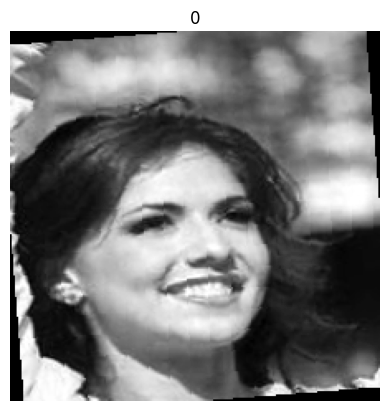

In [10]:
import matplotlib.pyplot as plt



def show_image(datapoint): 

    image, label = datapoint
    plt.imshow(image[0], cmap='gray')
    plt.title(label)
    plt.axis('off')
    plt.show()

show_image(train_dataset[0])

# Datamodule 

In [18]:
import lightning as pl 
from torch.utils.data import random_split, DataLoader


class GenderDataModule(pl.LightningDataModule):
    def __init__(self, train_dataset, val_dataset, batch_size=32, val_test_ratio = 0.2):
        super().__init__()
        self.train_dataset = train_dataset
        self.val_dataset = val_dataset
        self.batch_size = batch_size
        self.val_test_ratio = val_test_ratio

    def setup(self, stage=None):
        if stage == 'fit' or stage is None:
            self.train_data = self.train_dataset
            self.val_data = self.val_dataset
            
        elif stage == 'test':
            test_size = int(len(self.val_dataset) * self.val_test_ratio)
            val_size = len(self.val_dataset) - test_size

            self.val_data, self.test_data = random_split(self.val_dataset, [val_size, test_size])

    def train_dataloader(self):
        return DataLoader(self.train_data, batch_size=self.batch_size, shuffle=True, num_workers=4)

    def val_dataloader(self):
        return DataLoader(self.val_data, batch_size=self.batch_size, num_workers=4)

    def test_dataloader(self):
        return DataLoader(self.test_data, batch_size=self.batch_size, num_workers=4)


# Define model 

In [19]:
import torch.nn as nn 
import torch.optim as optim
import torchvision.models as models


class GenderPretrained: 

    @staticmethod
    def create_resnet18(num_classes=2, pretrained=True):
        model = models.resnet18(pretrained=pretrained)
        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        return model

    @staticmethod
    def create_resnet50(num_classes=2, pretrained=True):
        model = models.resnet50(pretrained=pretrained)
        num_features = model.fc.in_features
        model.fc = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        return model
    

    @staticmethod
    def create_efficientnet(num_classes=2, pretrained=True):
        model = models.efficientnet_b0(pretrained=pretrained)
        num_features = model.classifier.in_features
        model.classifier = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
        return model
    




In [20]:
from torchmetrics import Accuracy, F1Score, Precision, Recall


def get_model(model_name: str, num_classes: int = 2, pretrained: bool = True):
    if model_name == 'resnet18':
        return GenderPretrained.create_resnet18(num_classes, pretrained)
    elif model_name == 'resnet50':
        return GenderPretrained.create_resnet50(num_classes, pretrained)
    elif model_name == 'efficientnet':
        return GenderPretrained.create_efficientnet(num_classes, pretrained)
    else:
        raise ValueError(f"Model {model_name} not recognized. Choose from 'resnet18', 'resnet50', or 'efficientnet'.")


class GenderModule(pl.LightningModule):
    def __init__(self, model_name: str):
        super().__init__()
        self.model = get_model(model_name)

        self.criterion = nn.CrossEntropyLoss()

        self.train_acc = Accuracy(task = 'multiclass', num_classes=2)
        self.val_acc = Accuracy(task = 'multiclass', num_classes=2)
        self.test_acc = Accuracy(task = 'multiclass', num_classes=2)

        self.val_f1 = F1Score(task = 'multiclass', num_classes=2)
        self.val_precision = Precision(task = 'multiclass', num_classes=2)
        self.val_recall = Recall(task = 'multiclass', num_classes=2)

        self.test_f1 = F1Score(task = 'multiclass', num_classes=2)
        self.test_precision = Precision(task = 'multiclass', num_classes=2)
        self.test_recall = Recall(task = 'multiclass', num_classes=2)
        self.save_hyperparameters()

        

    def forward(self, x):
        return self.model(x)
    


    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x)
        loss = self.criterion(y_hat, y)
        acc = self.train_acc(y_hat, y)
        self.log('train_loss', loss)

        self.log('train_acc', acc, on_step=True, prog_bar=True)
        self.log('train_acc_epoch', self.train_acc, on_epoch=True, prog_bar=True)

        return loss
    

    def validation_step(self, batch, batch_idx):
        x, y = batch 
        y_hat = self(x)
        loss = self.criterion(y_hat, y)

        acc = self.val_acc(y_hat, y)
        f1 = self.val_f1(y_hat, y)
        precision = self.val_precision(y_hat, y)
        recall = self.val_recall(y_hat, y)

        self.log('val_loss', loss, on_step=True, prog_bar=True)
        self.log('val_acc', acc, on_step=True, prog_bar=True)
        self.log('val_f1', f1, on_step=True, prog_bar=True)
        self.log('val_precision', precision, on_step=True, prog_bar=True)
        self.log('val_recall', recall, on_step=True, prog_bar=True)



    def test_step(self, batch, batch_idx):
        x, y = batch 
        y_hat = self(x)
        loss = self.criterion(y_hat, y)

        acc = self.test_acc(y_hat, y)
        f1 = self.test_f1(y_hat, y)
        precision = self.test_precision(y_hat, y)
        recall = self.test_recall(y_hat, y)

        self.log('test_loss', loss, on_step=True, prog_bar=True)
        self.log('test_acc', acc, on_step=True, prog_bar=True)
        self.log('test_f1', f1, on_step=True, prog_bar=True)
        self.log('test_precision', precision, on_step=True, prog_bar=True)
        self.log('test_recall', recall, on_step=True, prog_bar=True)



    def configure_optimizers(self):
        optimizer = optim.AdamW(self.parameters(), lr=1e-4, weight_decay=1e-2)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)
        return {
            'optimizer': optimizer,
            'lr_scheduler': {
                'scheduler': scheduler,
                'monitor': 'val_acc',
                'interval': 'epoch',
                'frequency': 1
            }
        }



In [21]:
config = {
    'model_name': 'resnet18',
    'batch_size': 32,
    'max_epochs': 10,
    'gpus': 1,
    'num_workers': 4,
    'val_test_ratio': 0.2,
}

In [22]:
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping
import wandb


wandb.login(
  key = WANDB_API_KEY
)

wandb_logger = WandbLogger(
      name = config['model_name'],
      project = "Gender Classification",
      log_model = True
)

model_checkpoint = ModelCheckpoint(
      dirpath='checkpoints/',
      filename='{epoch}-{val_loss:.2f}',
      monitor='val_loss',
      save_top_k=3,
      mode='min',
      save_weights_only=True
)

early_stopping = EarlyStopping(
      monitor='val_loss',
      patience=3,
      verbose=False,
      mode='min'
)

trainer = pl.Trainer(
    accelerator = "cuda",
    devices = config['gpus'],
    max_epochs = config['max_epochs'],
    callbacks = [early_stopping, model_checkpoint],
    logger = wandb_logger
)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.
/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/thviet/.local/lib/python3.11/site-packages/ipy ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [23]:
!echo $$

model = GenderModule(config['model_name'])
data_module = GenderDataModule(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    batch_size=config['batch_size'],
    val_test_ratio=config['val_test_ratio']
)


trainer.fit(model, data_module)

1709930


/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/lightning/pytorch/loggers/wandb.py:397: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` bef

Epoch 6: 100%|██████████| 250/250 [00:21<00:00, 11.54it/s, v_num=i4k3, train_acc=0.969, train_acc_epoch_step=0.969, val_loss_step=0.648, val_acc_step=0.875, val_f1_step=0.875, val_precision_step=0.875, val_recall_step=0.875, val_loss_epoch=0.0942, val_acc_epoch=0.976, val_f1_epoch=0.976, val_precision_epoch=0.976, val_recall_epoch=0.976, train_acc_epoch_epoch=0.990] 


In [24]:
trainer.test(model, data_module)
wandb.finish()

/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /home/thviet/.local/lib/python3.11/site-packages/ipy ...
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00,  8.19it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_acc_epoch       │    0.9800000190734863     │
│       test_f1_epoch       │    0.9800000190734863     │
│      test_loss_epoch      │    0.09094186127185822    │
│   test_precision_epoch    │    0.9800000190734863     │
│     test_recall_epoch     │    0.9800000190734863     │
└───────────────────────────┴───────────────────────────┘

epoch,▁▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇█
test_acc_epoch,▁
test_acc_step,▆███▆▆▁
test_f1_epoch,▁
test_f1_step,▆███▆▆▁
test_loss_epoch,▁
test_loss_step,▂▁▁▁▃▂█
test_precision_epoch,▁
test_precision_step,▆███▆▆▁
test_recall_epoch,▁
test_recall_step,▆███▆▆▁


In [25]:
import torch 
from PIL import Image
from tqdm import tqdm
from pathlib import Path
import os
import pandas as pd




model_path = 'checkpoints/epoch=3-val_loss=0.05.ckpt'
model = GenderModule.load_from_checkpoint(model_path)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.eval()

def process_image(img_path):
    img = Image.open(img_path).convert('RGB')
    return val_test_transform(img).unsqueeze(0).to(device)

test_files = sorted([f for f in os.listdir(TEST_PATH) if f.endswith(('.jpg', '.jpeg', '.png'))])

results = []

with torch.no_grad():
    for file_name in tqdm(test_files, desc="testing"):
        img_id = Path(file_name).stem

        img_path = os.path.join(TEST_PATH, file_name)

        img = process_image(img_path)
        pred = model(img)
        pred_class = torch.argmax(pred, dim=1).item()


        results.append({
            "ID": img_id,
            "Label": pred_class
        })


df = pd.DataFrame(results)

csv_path = "gender_predictions.csv"
df.to_csv(csv_path, index=False)


print(f"Predictions saved to {csv_path}")

/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/workspace/thviet/paracrawl/tools/miniconda3/envs/img_env/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
testing: 100%|██████████| 1000/1000 [00:48<00:00, 20.73it/s]


Predictions saved to gender_predictions.csv


In [7]:
import pandas as pd 

csv_path = "gender_predictions.csv"
df = pd.read_csv(csv_path)

# Swap labels: 0 becomes 1, 1 becomes 0
df['Label'] = df['Label'].apply(lambda x: 1 if x == 0 else 0)

# Ensure ID is formatted with 6 digits (leading zeros if necessary)
df['ID'] = df['ID'].apply(lambda x: f"{x:06d}")

# Save the updated CSV with ID column preserved in 6-digit format
df.to_csv("gender_predictions_1.csv", index=False)
print(f"Updated predictions saved to gender_predictions_1.csv")

# Display the first few rows of the updated dataframe
df.head()

Updated predictions saved to gender_predictions_1.csv


,ID,Label
0,000067,0
1,000167,1
2,000480,1
3,000488,1
4,000570,1


In [5]:
df = pd.read_csv(csv_path)

In [6]:
df

,ID,Label
0,67,1
1,167,0
2,480,0
3,488,0
4,570,0
...,...,...
995,159239,1
996,159389,0
997,159808,0
998,159946,0
